# Systematic Equity Market-Neutral Strategy
### ML-Driven Long/Short Equity — Full Walkthrough

**Architecture**
```
data_loader.py  →  factors.py  →  signals.py  →  portfolio.py  →  backtest.py  →  analytics.py
```

| Step | Module | Description |
|------|--------|-------------|
| 1 | `data_loader` | Price universe (simulated or real via yfinance / CSV) |
| 2 | `factors` | MOM_1M, MOM_3M, MOM_12M, VOL_1M, BETA — z-scored cross-sectionally |
| 3 | `signals` | Rolling Ridge regression → predicted alpha scores |
| 4 | `portfolio` | Regularised Markowitz with dollar-neutral + beta-neutral constraints |
| 5 | `backtest` | Weekly rebalancing, 10 bps TC, daily P&L |
| 6 | `analytics` | Sharpe, Calmar, Max DD, NAV chart, drawdown chart |

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

---
## 1 · Configuration

In [2]:
from strategy.config import *

print(f"Universe      : {N_STOCKS} stocks")
print(f"History       : {N_DAYS} trading days from {START_DATE}")
print(f"Rebal freq    : every {REBAL_FREQ} business days")
print(f"Train window  : {TRAIN_WINDOW} weeks rolling")
print(f"Ridge α       : {RIDGE_ALPHA}")
print(f"Long/Short N  : top/bottom {TOP_N}")
print(f"λ Markowitz   : {LAMBDA_REG}")
print(f"TC            : {TRANSACTION_COST_BPS} bps one-way")

Universe      : 500 stocks
History       : 1500 trading days from 2018-01-01
Rebal freq    : every 5 business days
Train window  : 104 weeks rolling
Ridge α       : 10.0
Long/Short N  : top/bottom 50
λ Markowitz   : 5.0
TC            : 10.0 bps one-way


---
## 2 · Data Loading

By default we use simulated data. Uncomment the yfinance block to use real prices.

In [3]:
from strategy.data_loader import simulate_universe  # load_from_yfinance, load_from_csv

prices, true_betas = simulate_universe(
    n_stocks=N_STOCKS, n_days=N_DAYS, start_date=START_DATE, seed=RANDOM_SEED
)

# ── Real data (uncomment to use) ──────────────────────────────────────────
# from strategy.data_loader import load_from_yfinance
# import pandas as pd
# sp500_tickers = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]['Symbol'].tolist()
# prices = load_from_yfinance(sp500_tickers[:100], start='2018-01-01')
# true_betas = np.ones(prices.shape[1])  # will be estimated from data

market_prices = prices.mean(axis=1)

print(f"Prices shape  : {prices.shape}")
print(f"Date range    : {prices.index[0].date()} → {prices.index[-1].date()}")
prices.iloc[:3, :5]

Prices shape  : (1500, 500)
Date range    : 2018-01-01 → 2023-09-29


,STK000,STK001,STK002,STK003,STK004
2018-01-01,98.109888,99.141844,98.820649,100.531946,102.944746
2018-01-02,96.127300,100.212713,99.906519,98.751028,104.151892
2018-01-03,96.081423,99.583959,100.009262,101.041000,103.723072


---
## 3 · Factor Construction

In [4]:
from strategy.factors import compute_factors, cross_sectional_zscore

print("Computing raw factors…")
factors_raw  = compute_factors(prices, market_prices)

print("Normalising (cross-sectional z-score, winsorise ±3σ)…")
factors_norm = cross_sectional_zscore(factors_raw)

print(f"\nFactor panel: {factors_norm.shape}")
print(f"Factors     : {list(factors_norm.columns.get_level_values(0).unique())}")

Computing raw factors…
Normalising (cross-sectional z-score, winsorise ±3σ)…

Factor panel: (1500, 2500)
Factors     : ['MOM_1M', 'MOM_3M', 'MOM_12M', 'VOL_1M', 'BETA']


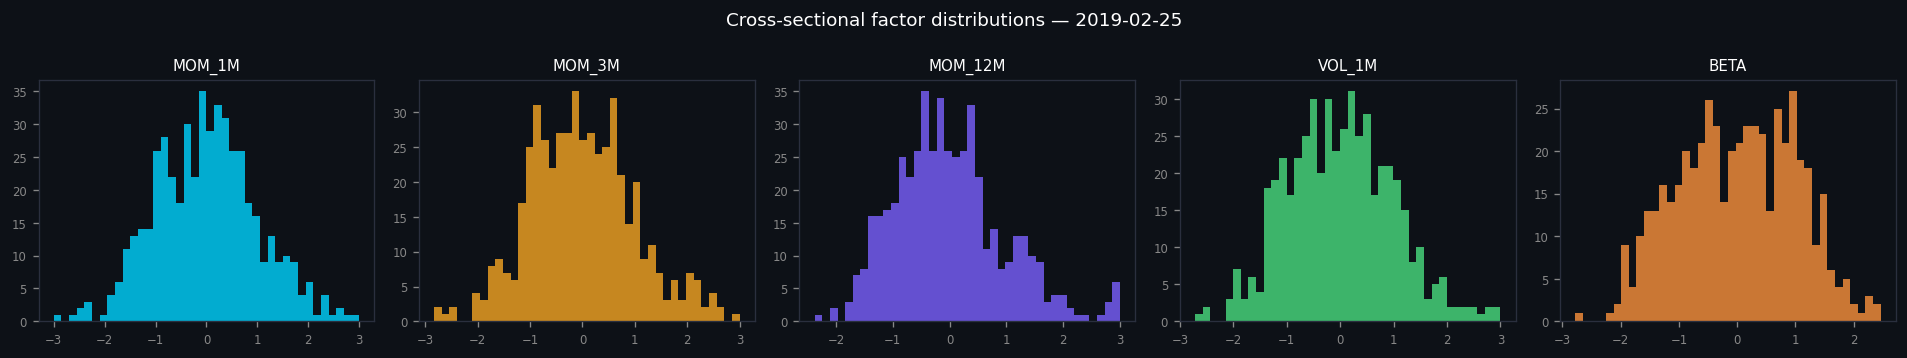

In [5]:
# Visualise cross-sectional factor distributions on a given date
sample_date = factors_norm.index[300]
fig, axes = plt.subplots(1, 5, figsize=(16, 3), facecolor='#0d1117')
factor_names = list(factors_norm.columns.get_level_values(0).unique())
colors = ['#00d4ff', '#f5a623', '#7b61ff', '#4ade80', '#fb923c']

for ax, fname, col in zip(axes, factor_names, colors):
    data = factors_norm[fname].loc[sample_date].dropna()
    ax.hist(data, bins=40, color=col, alpha=0.8, edgecolor='none')
    ax.set_title(fname, color='white', fontsize=9)
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='#888', labelsize=7)
    for spine in ax.spines.values(): spine.set_edgecolor('#2a2f3e')

fig.suptitle(f'Cross-sectional factor distributions — {sample_date.date()}',
             color='white', fontsize=11)
plt.tight_layout()
plt.show()

---
## 4 · Signal Generation (Rolling Ridge Regression)

In [6]:
from strategy.signals import generate_signals

# Forward return target: next-week return
fwd_returns = prices.pct_change(REBAL_FREQ).shift(-REBAL_FREQ)

print("Training rolling Ridge regression…  (this may take 1-2 min)")
signals = generate_signals(
    factors_norm, fwd_returns,
    train_window=TRAIN_WINDOW,
    rebal_freq=REBAL_FREQ,
    alpha=RIDGE_ALPHA,
)

print(f"\nSignals shape : {signals.shape}")
print(f"Rebal dates   : {signals.index[0].date()} → {signals.index[-1].date()}")
signals.iloc[:3, :5]

Training rolling Ridge regression…  (this may take 1-2 min)
      Signal 1/196  (2019-12-30)
      Signal 20/196  (2020-05-11)
      Signal 40/196  (2020-09-28)
      Signal 60/196  (2021-02-15)
      Signal 80/196  (2021-07-05)
      Signal 100/196  (2021-11-22)
      Signal 120/196  (2022-04-11)
      Signal 140/196  (2022-08-29)
      Signal 160/196  (2023-01-16)
      Signal 180/196  (2023-06-05)

Signals shape : (196, 500)
Rebal dates   : 2019-12-30 → 2023-09-25


,STK000,STK001,STK002,STK003,STK004
2019-12-30,0.001667,0.002583,0.001894,0.001609,0.001362
2020-01-06,0.003018,0.001721,0.001796,0.000660,0.000910
2020-01-13,0.001979,0.001200,0.000664,0.000826,0.000704


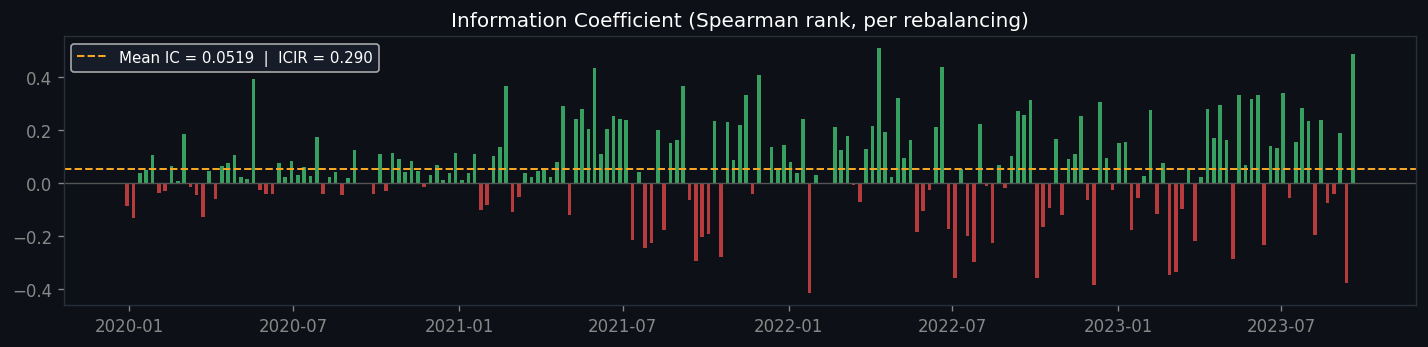

Mean IC : 0.0519  |  ICIR : 0.2897


In [7]:
# Signal rank correlation with forward returns (information coefficient)
from scipy.stats import spearmanr

ics = []
for d in signals.index:
    if d not in fwd_returns.index: continue
    s = signals.loc[d].dropna()
    r = fwd_returns.loc[d].reindex(s.index).dropna()
    common = s.index.intersection(r.index)
    if len(common) < 30: continue
    ic, _ = spearmanr(s[common], r[common])
    ics.append({'date': d, 'IC': ic})

ic_df = pd.DataFrame(ics).set_index('date')
ic_mean = ic_df['IC'].mean()
icir    = ic_df['IC'].mean() / ic_df['IC'].std()

fig, ax = plt.subplots(figsize=(12, 3), facecolor='#0d1117')
ax.bar(ic_df.index, ic_df['IC'], color=np.where(ic_df['IC']>0,'#4ade80','#ff4d4d'), alpha=0.7, width=4)
ax.axhline(0, color='#555', lw=0.8)
ax.axhline(ic_mean, color='#f5a623', lw=1.2, ls='--', label=f'Mean IC = {ic_mean:.4f}  |  ICIR = {icir:.3f}')
ax.set_title('Information Coefficient (Spearman rank, per rebalancing)', color='white')
ax.set_facecolor('#0d1117'); ax.tick_params(colors='#888')
for spine in ax.spines.values(): spine.set_edgecolor('#2a2f3e')
ax.legend(facecolor='#1a1f2e', labelcolor='white', fontsize=9)
plt.tight_layout(); plt.show()

print(f"Mean IC : {ic_mean:.4f}  |  ICIR : {icir:.4f}")

---
## 5 · Portfolio Construction

Single-date demo — build one rebalancing period's portfolio and inspect it.

In [8]:
from strategy.portfolio import build_portfolio

t_demo  = signals.index[10]
t_idx   = prices.index.get_loc(t_demo)
cov_win = prices.pct_change().iloc[max(0, t_idx-60):t_idx]
cov_mat = cov_win.cov().fillna(0).values * 252

beta_s = pd.Series(true_betas, index=prices.columns)
w      = build_portfolio(signals.loc[t_demo], beta_s, cov_mat, list(prices.columns))

print(f"Date          : {t_demo.date()}")
print(f"Long  positions  : {(w>0).sum()}")
print(f"Short positions  : {(w<0).sum()}")
print(f"Dollar-neutral   : Σw = {w.sum():.6f}  (target 0)")
print(f"Beta-neutral     : β·w = {(beta_s * w).sum():.6f}  (target 0)")
print(f"Max weight       : {w.abs().max():.4f}  (limit {MAX_WEIGHT})")

Date          : 2020-03-09
Long  positions  : 49
Short positions  : 52
Dollar-neutral   : Σw = -0.000000  (target 0)
Beta-neutral     : β·w = 0.000000  (target 0)
Max weight       : 0.0145  (limit 0.1)


---
## 6 · Full Backtest

In [9]:
from strategy.backtest import run_backtest

print("Running full backtest…  (this may take several minutes)")
result = run_backtest(
    prices, signals, true_betas,
    transaction_cost_bps = TRANSACTION_COST_BPS,
    top_n                = TOP_N,
    lambda_reg           = LAMBDA_REG,
)
print("Done.")

Running full backtest…  (this may take several minutes)


  Backtesting: 100%|███████████████████████| 195/195 [04:38<00:00,  1.43s/rebal]

Done.


---
## 7 · Performance Analytics

In [10]:
from strategy.analytics import print_report, plot_results
print_report(result.metrics)


════════════════════════════════════════════
             PERFORMANCE SUMMARY            
════════════════════════════════════════════
  Total Return (%)                 -10.0
  Annualised Return (%)            -2.68
  Annualised Vol (%)                2.86
  Sharpe Ratio                    -0.939
  Max Drawdown (%)                -10.99
  Calmar Ratio                    -0.244
  Hit Rate (%)                     46.46
  Skewness                         0.038
  Excess Kurtosis                 -0.042
  Total Trading Days                 975
════════════════════════════════════════════



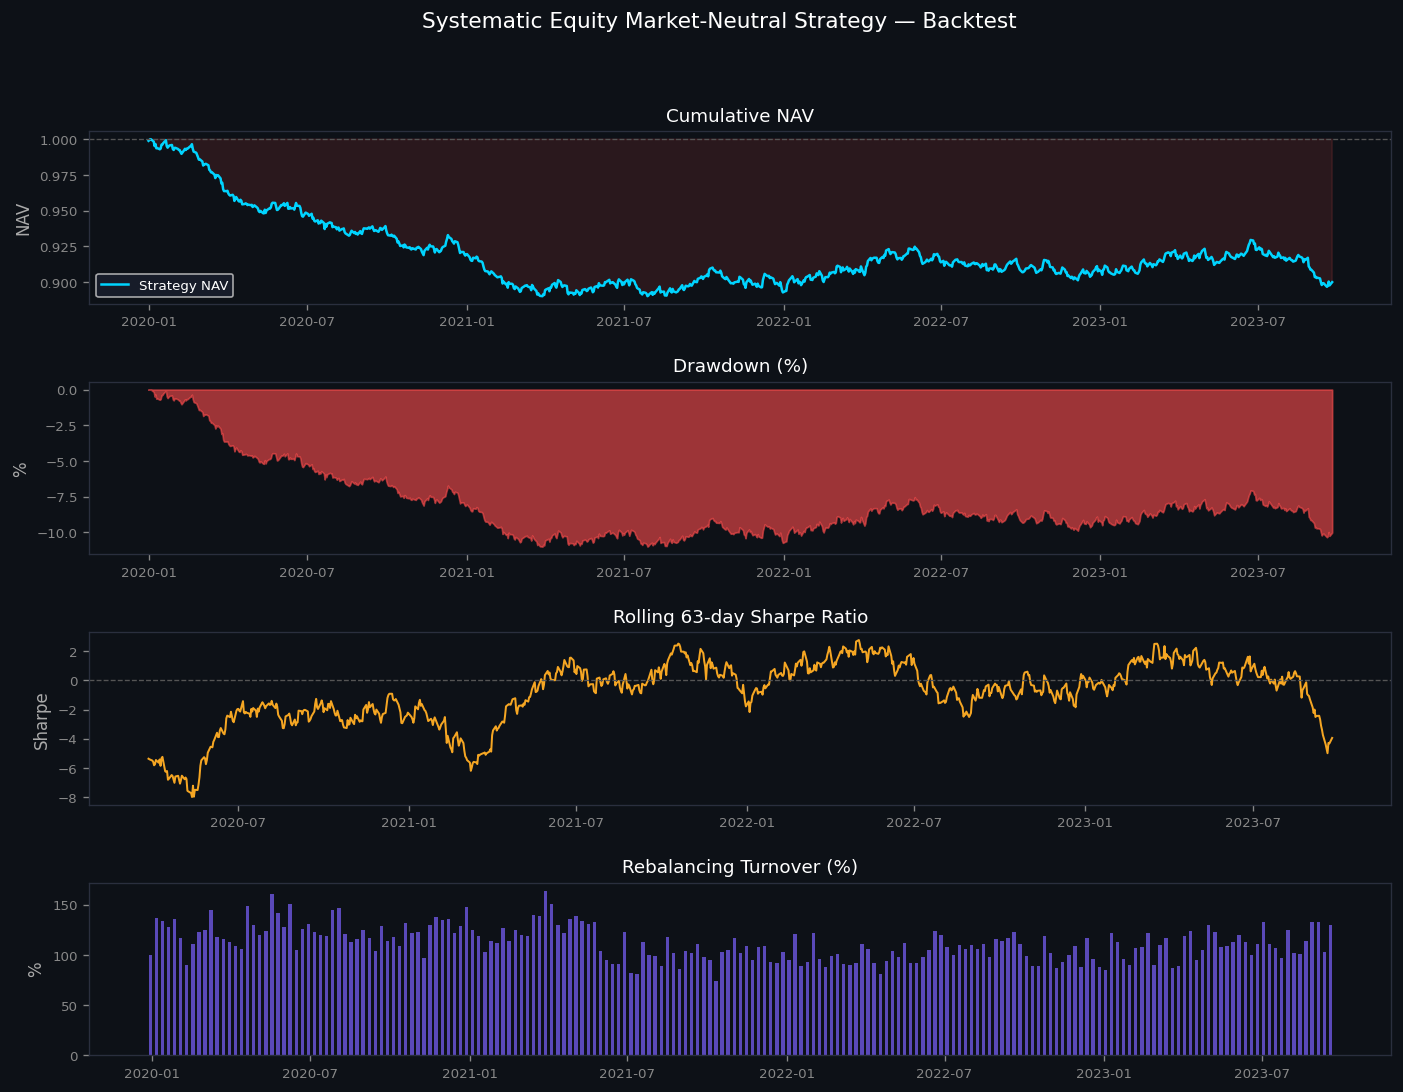

In [11]:
fig = plot_results(result)
plt.show()

---
## 8 · Monthly Returns Heatmap

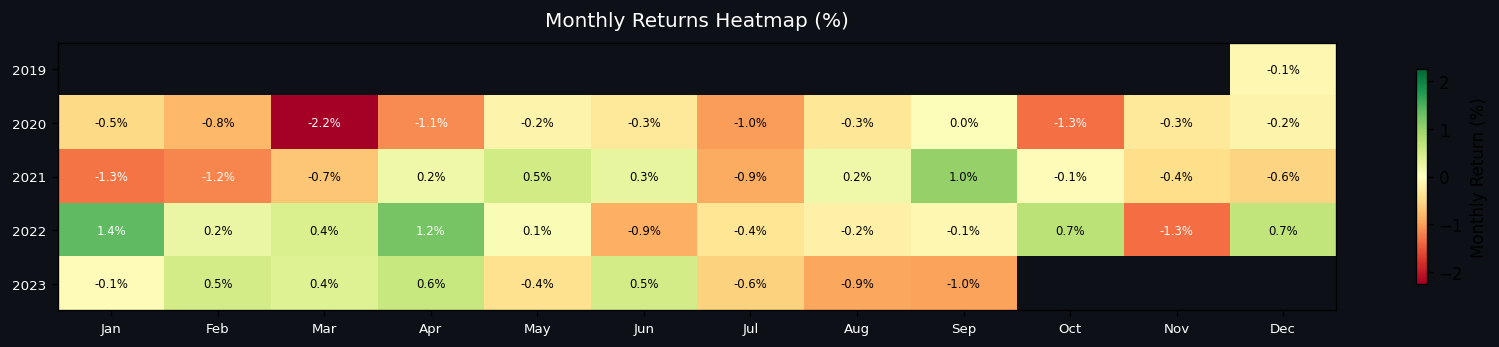

In [12]:
import matplotlib.colors as mcolors

monthly = result.returns.resample('ME').apply(lambda x: (1 + x).prod() - 1)
monthly_df = monthly.to_frame('ret')
monthly_df['year']  = monthly_df.index.year
monthly_df['month'] = monthly_df.index.month
pivot = monthly_df.pivot(index='year', columns='month', values='ret') * 100
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, max(3, len(pivot)*0.55)), facecolor='#0d1117')
cmap = plt.cm.RdYlGn
vmax = pivot.abs().max().max()
im   = ax.imshow(pivot.values, cmap=cmap, aspect='auto', vmin=-vmax, vmax=vmax)

ax.set_xticks(range(12)); ax.set_xticklabels(pivot.columns, color='white', fontsize=8)
ax.set_yticks(range(len(pivot))); ax.set_yticklabels(pivot.index, color='white', fontsize=8)
ax.set_facecolor('#0d1117')

for i in range(len(pivot)):
    for j in range(12):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                    color='black' if abs(val) < vmax * 0.5 else 'white', fontsize=7)

plt.colorbar(im, ax=ax, label='Monthly Return (%)', shrink=0.8)
ax.set_title('Monthly Returns Heatmap (%)', color='white', fontsize=12, pad=10)
plt.tight_layout(); plt.show()

---
## 9 · Save Outputs

Saved to outputs/
  backtest_dashboard.png
  daily_returns.csv
  ic_series.csv
  metrics.csv
  nav_series.csv


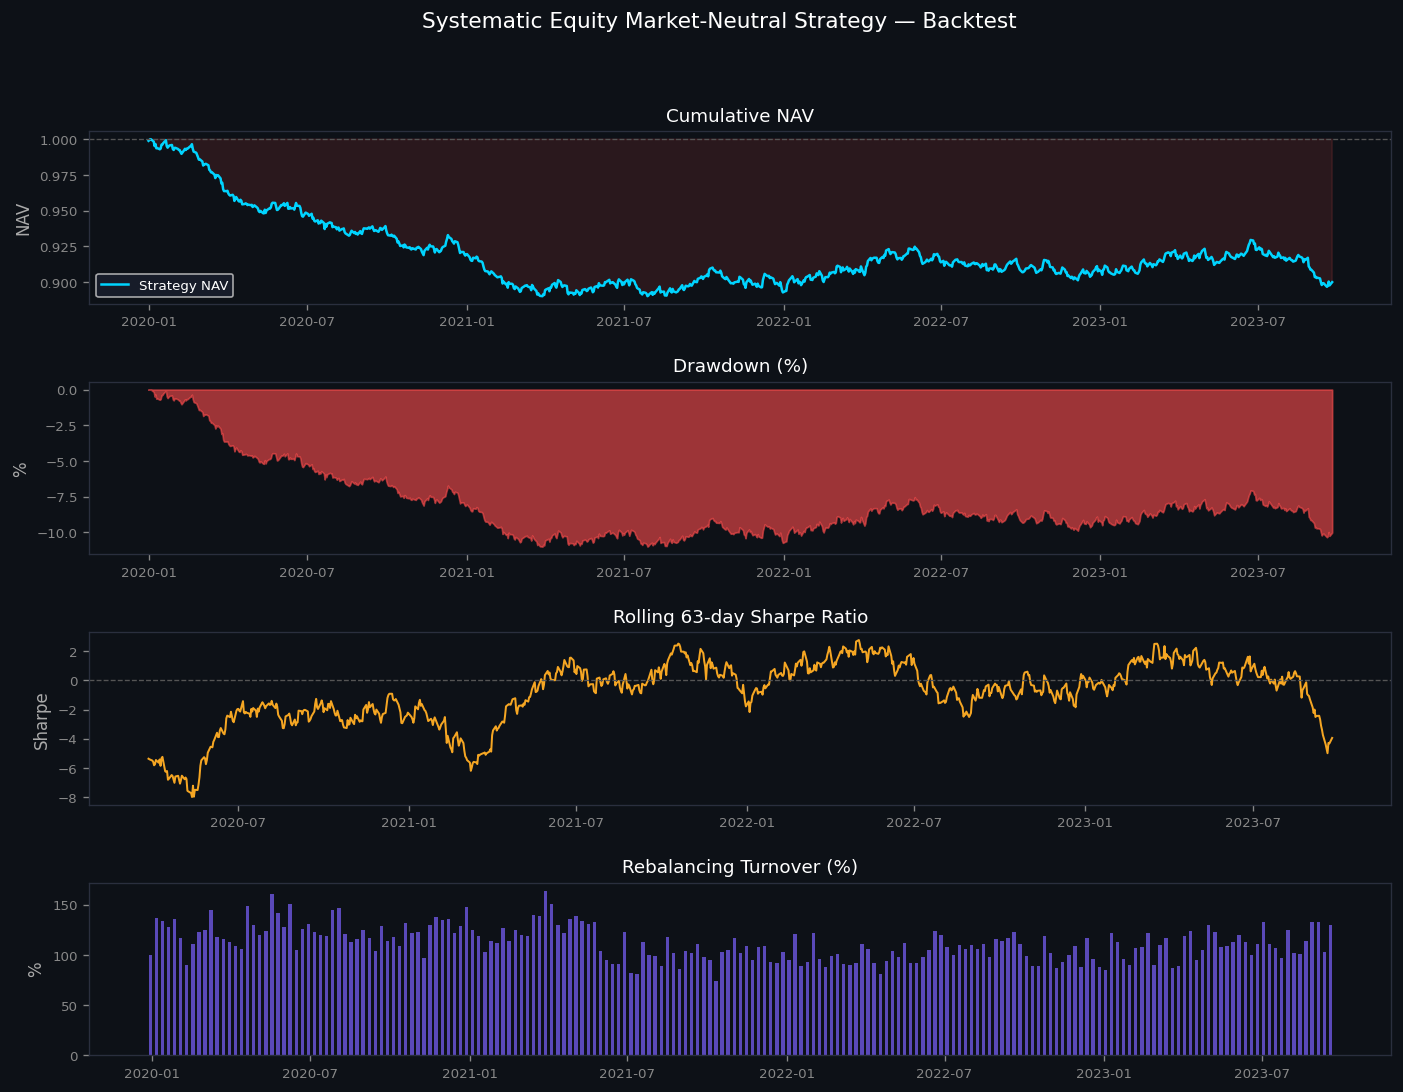

In [13]:
from pathlib import Path
out = Path('../outputs')
out.mkdir(exist_ok=True)

result.nav.to_csv(out / 'nav_series.csv')
result.returns.to_csv(out / 'daily_returns.csv')
pd.DataFrame(result.metrics, index=[0]).to_csv(out / 'metrics.csv', index=False)
ic_df.to_csv(out / 'ic_series.csv')

fig = plot_results(result)
fig.savefig(out / 'backtest_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')

print('Saved to outputs/')
for f in sorted(out.iterdir()): print(' ', f.name)